# **STEP 2: SQL IN R**


In [ ]:
# Install a package that lets us upload files
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Load the library
library(readr)

In [ ]:
# Load all the clean CSV files into R

customers  <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/customers_clean.csv")
orders     <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/orders_clean.csv")
deliveries <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/deliveries_clean.csv")
drivers    <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/drivers_clean.csv")
complaints <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/complaints_clean.csv")
incidents  <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/incidents_clean.csv")
vehicles   <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/vehicles_clean.csv")
hubs       <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/hubs.csv")
app_events <- read.csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/app_events_clean.csv")

print("All files loaded!")

[1] "All files loaded!"


In [ ]:
# Install sqldf package

install.packages("sqldf")
library(sqldf)

print("sqldf ready!")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



[1] "sqldf ready!"


Query 1 — Count how many orders each service type has:

In [ ]:
# SQL query inside R using sqldf
# This counts how many orders exist for each service type

query1 <- sqldf("
  SELECT service_type,
         COUNT(*) AS total_orders
  FROM orders
  GROUP BY service_type
  ORDER BY total_orders DESC
")

print(query1)

  service_type total_orders
1    Passenger          341
2       Parcel          308
3       Retail          297
4     Business          165
5      Medical          139


What it means:
Passenger services are the most used. Medical is the least. This tells NorthStar where most of their business comes from.

Query 2 — Count deliveries by status (OnTime, Delayed, Failed):

In [ ]:
query2 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")

print(query2)

  delivery_status total
1          OnTime   616
2         Delayed   202
3          Failed   132


What it means:
Out of 950 deliveries, 334 were either delayed or failed. That is about 35% failure rate — which is very high and a serious problem for NorthStar!

Query 3 — Which zones have the most orders?

In [ ]:
query3 <- sqldf("
  SELECT pickup_zone,
         COUNT(*) AS total_orders
  FROM orders
  GROUP BY pickup_zone
  ORDER BY total_orders DESC
")

print(query3)

  pickup_zone total_orders
1        East          207
2       South          181
3       North          174
4     Central          158
5        West          155
6   Riverside          151
7     Airport          144
8         Ctr           80


What it means:
East zone is the busiest. "Ctr" appears to be a data quality issue — it likely means "Central" but was entered differently. This confirms our earlier finding about inconsistent data.


Query 4 — Average customer rating per delivery status:

In [ ]:
query4 <- sqldf("
  SELECT delivery_status,
         ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY avg_rating DESC
")

print(query4)

  delivery_status avg_rating
1          OnTime       4.28
2         Delayed       3.14
3          Failed       3.06


What it means:
Customers clearly rate failed and delayed deliveries much lower. This directly links poor delivery performance to customer dissatisfaction.

Query 5 — Top 5 most complained about order types:

In [ ]:
query5 <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total_complaints
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
  LIMIT 5
")

print(query5)

     complaint_type total_complaints
1             Delay              101
2      MissedPickup               64
3          AppIssue               53
4   DriverBehaviour               51
5 SupportExperience               20


What it means:
Delays are the biggest complaint — which matches our Query 2 finding. Missed pickups and app issues are also significant problems.

Query 6 — Which driver has the highest average rating?

In [ ]:
query6 <- sqldf("
  SELECT driver_id,
         ROUND(AVG(driver_rating), 2) AS avg_rating
  FROM drivers
  GROUP BY driver_id
  ORDER BY avg_rating DESC
  LIMIT 10
")

print(query6)

   driver_id avg_rating
1       D086       5.00
2       D070       5.00
3       D069       5.00
4       D055       5.00
5       D003       5.00
6       D139       4.99
7       D121       4.97
8       D118       4.88
9       D067       4.84
10      D107       4.82


What it means:
The top rated drivers are identified. NorthStar should study what these
drivers do differently and use them as a model for training other drivers.

Query 7 — Total order value per service type?

In [ ]:
query7 <- sqldf("
  SELECT service_type,
         ROUND(SUM(order_value), 2) AS total_value
  FROM orders
  GROUP BY service_type
  ORDER BY total_value DESC
")

print(query7)

  service_type total_value
1    Passenger    32761.11
2       Parcel    26985.62
3       Retail    26734.06
4     Business    15220.43
5      Medical    12111.93


What it means:
Passenger services generate the most revenue. Medical generates least — NorthStar should check if medical routes are profitable.

Query 8 — How many high severity incidents are there?

In [ ]:
query8 <- sqldf("
  SELECT severity,
         COUNT(*) AS total_incidents
  FROM incidents
  GROUP BY severity
  ORDER BY total_incidents DESC
")

print(query8)

  severity total_incidents
1   Medium             106
2      Low              79
3     High              68
4 Critical              27


What it means:
27 critical incidents is very concerning. Combined with 68 high severity incidents, NorthStar has 95 serious incidents that need urgent attention.

Query 9 — Average fuel cost per hub

In [ ]:
query9 <- sqldf("
  SELECT hub_id,
         ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_cost
  FROM deliveries
  GROUP BY hub_id
  ORDER BY avg_fuel_cost DESC
")

print(query9)

  hub_id avg_fuel_cost
1    H05         13.69
2    H06         13.32
3    H04         13.17
4    H07         12.92
5    H01         12.76
6    H03         12.74
7    H02         12.57
8    H08         11.71


What it means:
Hub H05 is costing NorthStar the most in fuel/charging. This could mean longer routes or inefficient vehicle assignments at that h

Query 10 — Join orders and complaints to see which service type complains most

In [ ]:
query10 <- sqldf("
  SELECT o.service_type,
         COUNT(*) AS total_complaints
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY total_complaints DESC
")

print(query10)

  service_type total_complaints
1    Passenger               84
2       Retail               83
3       Parcel               77
4     Business               39
5      Medical               37


What it means:
Passenger services have the most complaints AND the most orders — so NorthStar's busiest service is also their most problematic. Retail complaints are almost equal to Passenger which is also concerning.

Query 11 — Count manual route overrides by hub

In [ ]:
query11 <- sqldf("
  SELECT hub_id,
         SUM(manual_route_override_count) AS total_overrides
  FROM deliveries
  GROUP BY hub_id
  ORDER BY total_overrides DESC
")

print(query11)

  hub_id total_overrides
1    H08             142
2    H01             140
3    H07             121
4    H04             111
5    H05             109
6    H03             106
7    H02              97
8    H06              95


What it means:
H08 has the most manual route overrides — meaning drivers are frequently ignoring the planned routes. This could mean poor route planning at H08 or genuine road problems in that area.

Query 12 — Only show Failed deliveries with high fuel cost

In [ ]:
query12 <- sqldf("
  SELECT delivery_id,
         hub_id,
         delivery_status,
         fuel_or_charge_cost
  FROM deliveries
  WHERE delivery_status = 'Failed'
  AND fuel_or_charge_cost > 15
  ORDER BY fuel_or_charge_cost DESC
")

print(query12)

   delivery_id hub_id delivery_status fuel_or_charge_cost
1      DL00664    H07          Failed               25.46
2      DL00119    H03          Failed               25.09
3      DL00582    H05          Failed               22.61
4      DL00928    H05          Failed               21.60
5      DL00533    H08          Failed               21.32
6      DL00240    H06          Failed               21.21
7      DL00825    H05          Failed               21.03
8      DL00515    H04          Failed               21.00
9      DL00838    H03          Failed               20.66
10     DL00938    H03          Failed               20.16
11     DL00432    H05          Failed               19.62
12     DL00788    H05          Failed               19.57
13     DL00530    H01          Failed               19.50
14     DL00235    H05          Failed               19.15
15     DL00558    H05          Failed               18.56
16     DL00482    H02          Failed               18.23
17     DL00033

41 failed deliveries cost more than £15
H05 appears most frequently
Highest cost = £25.46 (DL00664)

What it means:
H05 hub has the most expensive failed deliveries. Money is being wasted on deliveries that didn't even succeed. This is a serious cost problem for NorthStar.


Query 13 — High severity complaints that are still Open

In [ ]:
query13 <- sqldf("
  SELECT complaint_id,
         complaint_type,
         severity,
         status,
         resolution_days
  FROM complaints
  WHERE severity = 'High'
  AND status = 'Open'
  ORDER BY resolution_days DESC
")

print(query13)

   complaint_id  complaint_type severity status resolution_days
1        CP0287 DriverBehaviour     High   Open              20
2        CP0294        AppIssue     High   Open              19
3        CP0261        AppIssue     High   Open              18
4        CP0003           Delay     High   Open              16
5        CP0133           Delay     High   Open              15
6        CP0147 DriverBehaviour     High   Open              15
7        CP0266          Damage     High   Open              15
8        CP0131           Delay     High   Open              14
9        CP0001        AppIssue     High   Open              11
10       CP0283 DriverBehaviour     High   Open              11
11       CP0299           Delay     High   Open              11
12       CP0161         Billing     High   Open               9
13       CP0174 DriverBehaviour     High   Open               9
14       CP0195           Delay     High   Open               8


14 high severity complaints still unresolved
CP0287 waiting 20 days (longest)
Delay and Driver Behaviour are most common

What it means:
Some serious complaints have been waiting up to 20 days without resolution. This directly damages customer trust and satisfaction.

Query 14 — Drivers with low rating and many years experience

In [ ]:
query14 <- sqldf("
  SELECT driver_id,
         base_zone,
         years_experience,
         driver_rating
  FROM drivers
  WHERE driver_rating < 3.5
  AND years_experience > 5
  ORDER BY driver_rating ASC
")

print(query14)

   driver_id base_zone years_experience driver_rating
1       D095      West               12          3.15
2       D128   Central               13          3.32
3       D024 Riverside                8          3.35
4       D022      East                9          3.36
5       D042     North                9          3.37
6       D052 Riverside                8          3.39
7       D141     North               14          3.44
8       D048      East                7          3.45
9       D104      West               15          3.45
10      D099     North               10          3.48


10 drivers with 7+ years experience but rating below 3.5
D095 has 12 years experience but only 3.15 rating

What it means:
These drivers have lots of experience but are still performing poorly. This suggests a training or motivation problem rather than inexperience.

-Unoptimized Query -

In [ ]:
# Unoptimised - gets ALL rows, no filter
# This is slow because it reads everything

result1 <- sqldf("SELECT * FROM deliveries")
cat("Rows returned without filter:", nrow(result1), "\n")

Rows returned without filter: 950 


-Optimized Query

In [ ]:
# Optimised - uses WHERE to get only what we need
# This is faster because it skips unnecessary rows

result2 <- sqldf("
  SELECT * FROM deliveries
  WHERE delivery_status = 'Failed'
")
cat("Rows returned with filter:", nrow(result2), "\n")
cat("Reduced from", nrow(result1), "to", nrow(result2), "rows!\n")

Rows returned with filter: 132 
Reduced from 950 to 132 rows!


# CHARTS for SQL in R

Chart 1 — Orders by Service Type

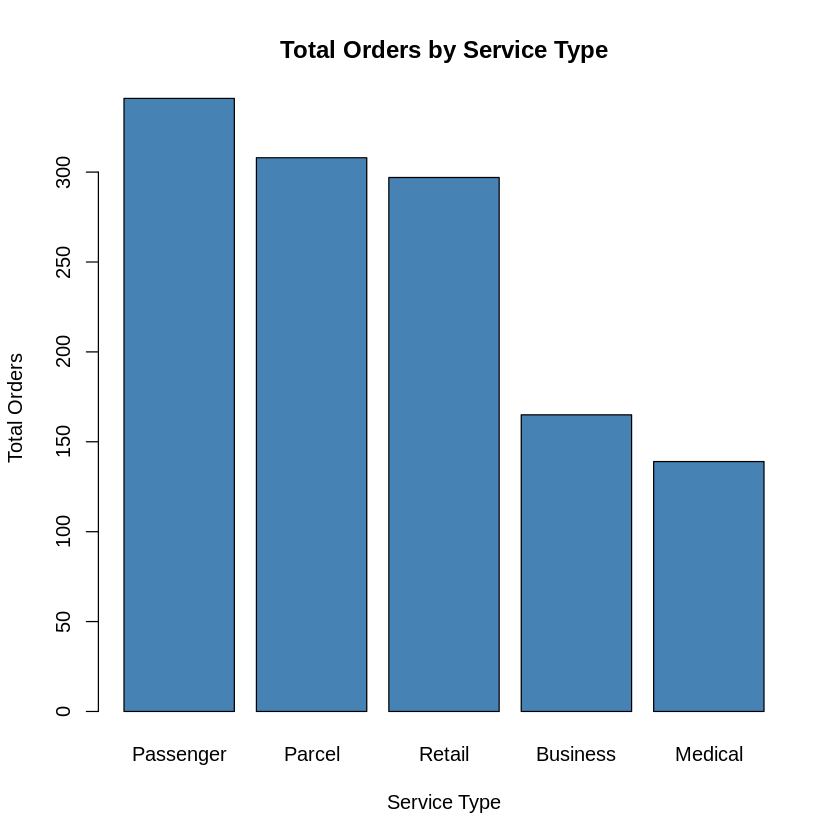

In [ ]:
# Simple bar chart for orders by service type

barplot(query1$total_orders,
        names.arg = query1$service_type,
        main = "Total Orders by Service Type",
        xlab = "Service Type",
        ylab = "Total Orders",
        col = "steelblue")

Chart 2 — Delivery Status

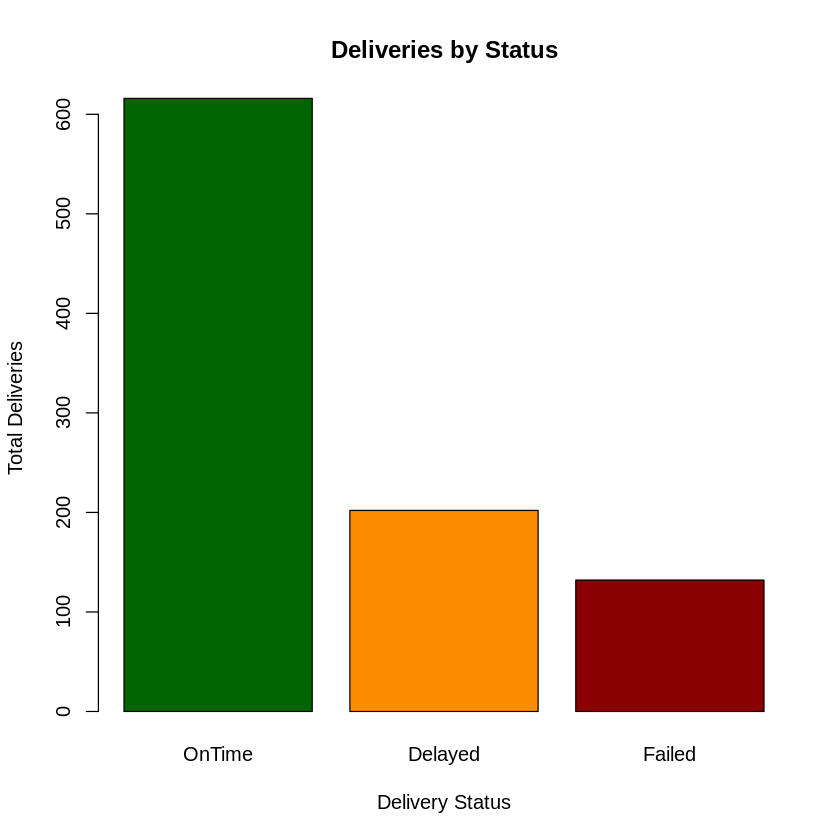

In [ ]:
# Bar chart for delivery status

barplot(query2$total,
        names.arg = query2$delivery_status,
        main = "Deliveries by Status",
        xlab = "Delivery Status",
        ylab = "Total Deliveries",
        col = c("darkgreen", "darkorange", "darkred"))

Chart 3 — Complaints by Type

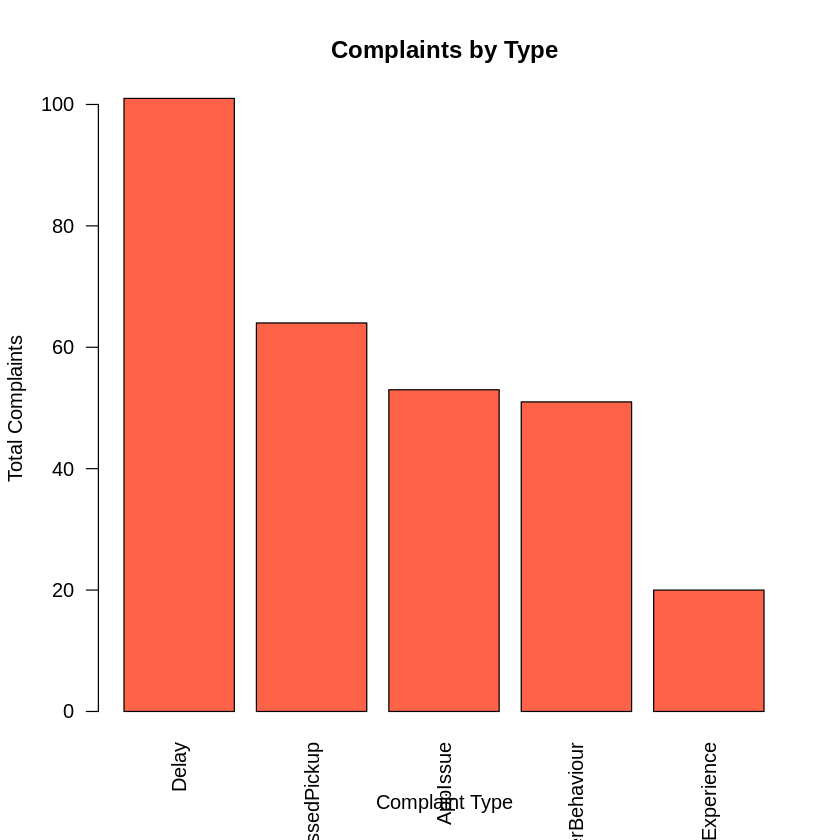

In [ ]:
# Bar chart for complaint types

barplot(query5$total_complaints,
        names.arg = query5$complaint_type,
        main = "Complaints by Type",
        xlab = "Complaint Type",
        ylab = "Total Complaints",
        col = "tomato",
        las = 2)

Chart 4 — Route Overrides by Hub

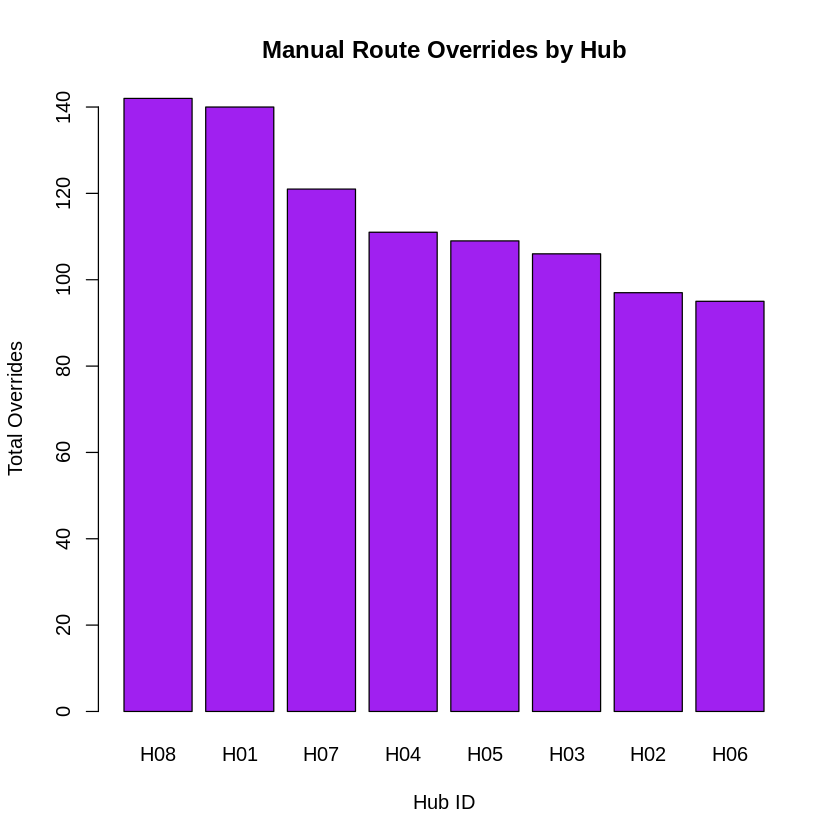

In [ ]:
# Bar chart for route overrides by hub

barplot(query11$total_overrides,
        names.arg = query11$hub_id,
        main = "Manual Route Overrides by Hub",
        xlab = "Hub ID",
        ylab = "Total Overrides",
        col = "purple")

# **STEP 3: R  ANALYTICS**

In [ ]:
# Install All Required Packages

install.packages("reshape2")
install.packages("ggplot2")
install.packages("dplyr")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Loading all packages

library(reshape2)
library(ggplot2)
library(dplyr)


print("All packages loaded!")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "All packages loaded!"


- Basic Statistical Analysis

In [ ]:
# Basic statistics for delivery data

cat("=== Delivery Statistics ===\n")
cat("Average customer rating:", mean(deliveries$customer_rating_post_delivery), "\n")
cat("Median customer rating:", median(deliveries$customer_rating_post_delivery), "\n")
cat("Average fuel cost:", mean(deliveries$fuel_or_charge_cost), "\n")
cat("Average route distance:", mean(deliveries$route_distance_km), "\n")

=== Delivery Statistics ===
Average customer rating: 3.867263 
Median customer rating: 4.04 
Average fuel cost: 12.84129 
Average route distance: 13.90932 


Deliveries:

Average rating is 3.87 out of 5 — not great, room for improvement

Average fuel cost is £12.84 per delivery

Average route distance is 13.9 km

In [ ]:
# Basic statistics for orders

cat("=== Order Statistics ===\n")
cat("Average order value:", mean(orders$order_value), "\n")
cat("Highest order value:", max(orders$order_value), "\n")
cat("Lowest order value:", min(orders$order_value), "\n")
cat("Median order value:", median(orders$order_value), "\n")

=== Order Statistics ===
Average order value: 91.05052 
Highest order value: 510.06 
Lowest order value: 2.04 
Median order value: 76.53 


Orders:

Average order value is £91 but median is only £76 — means some very high value orders are pulling the average up.

Highest single order is £510 — very high value customer

In [ ]:
# Basic statistics for drivers

cat("=== Driver Statistics ===\n")
cat("Average driver rating:", mean(drivers$driver_rating), "\n")
cat("Average training score:", mean(drivers$training_score), "\n")
cat("Average years experience:", mean(drivers$years_experience), "\n")

=== Driver Statistics ===
Average driver rating: 4.171706 
Average training score: 74.92647 
Average years experience: 8.223529 


Drivers:

Average driver rating 4.17 — decent but some pulling it down

Average training score 74.9 out of 100 — room for improvement



-Correlation Analysis


In [ ]:
# Correlation analysis
# This shows which numbers are related to each other

cat("=== Correlation Analysis ===\n")

# Does longer distance mean higher fuel cost?
cor1 <- cor(deliveries$route_distance_km, deliveries$fuel_or_charge_cost)
cat("Distance vs Fuel Cost correlation:", round(cor1, 2), "\n")

# Does higher fuel cost mean lower rating?
cor2 <- cor(deliveries$fuel_or_charge_cost, deliveries$customer_rating_post_delivery)
cat("Fuel Cost vs Customer Rating correlation:", round(cor2, 2), "\n")

# Does more experience mean better rating?
cor3 <- cor(drivers$years_experience, drivers$driver_rating)
cat("Driver Experience vs Rating correlation:", round(cor3, 2), "\n")

=== Correlation Analysis ===
Distance vs Fuel Cost correlation: 0.52 
Fuel Cost vs Customer Rating correlation: -0.06 
Driver Experience vs Rating correlation: 0.06 


-Data Manipulation Using dplyr

In [ ]:
# Count deliveries by status using dplyr
# group_by = group same values together
# summarise = calculate something for each group

delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total = n())

print(delivery_summary)

# A tibble: 3 × 2
  delivery_status total
  <chr>           <int>
1 Delayed           202
2 Failed            132
3 OnTime            616


In [ ]:
# Average rating per hub using dplyr

hub_rating <- deliveries %>%
  group_by(hub_id) %>%
  summarise(avg_rating = round(mean(customer_rating_post_delivery), 2))

print(hub_rating)

# A tibble: 8 × 2
  hub_id avg_rating
  <chr>       <dbl>
1 H01          3.84
2 H02          3.95
3 H03          3.9 
4 H04          3.92
5 H05          3.68
6 H06          3.88
7 H07          3.88
8 H08          3.89


-Reshape Data Using reshape2

In [ ]:
# Count complaints by type and severity
# dcast reshapes data into a table format - like a pivot table in Excel!

complaint_table <- dcast(complaints, complaint_type ~ severity,
                         value.var = "complaint_id",
                         fun.aggregate = length)

print(complaint_table)

     complaint_type High Low Medium
1          AppIssue   13  15     25
2           Billing    4   3      9
3            Damage    7   6      2
4             Delay   18  27     56
5   DriverBehaviour   16   4     31
6      MissedPickup   16  11     37
7 SupportExperience    3   5     12


Complaint Table

Delay complaints are highest across ALL severity levels.

56 medium severity delay complaints — biggest single problem.

18 high severity delay complaints — urgent issue.

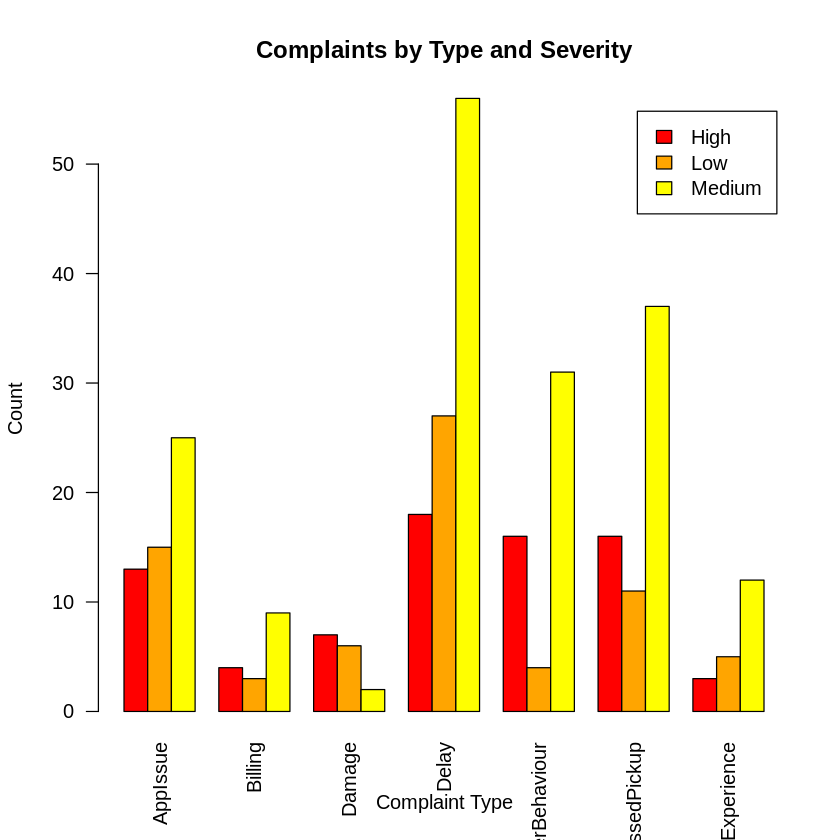

In [ ]:
# Complaints by type and severity

complaint_melt <- melt(complaint_table, id.vars = "complaint_type")
colnames(complaint_melt) <- c("complaint_type", "severity", "count")

complaint_matrix <- as.matrix(complaint_table[, 2:4])
rownames(complaint_matrix) <- complaint_table$complaint_type

barplot(t(complaint_matrix),
        beside = TRUE,
        main = "Complaints by Type and Severity",
        xlab = "Complaint Type",
        ylab = "Count",
        col = c("red", "orange", "yellow"),
        legend.text = c("High", "Low", "Medium"),
        las = 2)

-Visualisation Chart Using ggplot2

Chart 1 — Bar Chart of Delivery Status

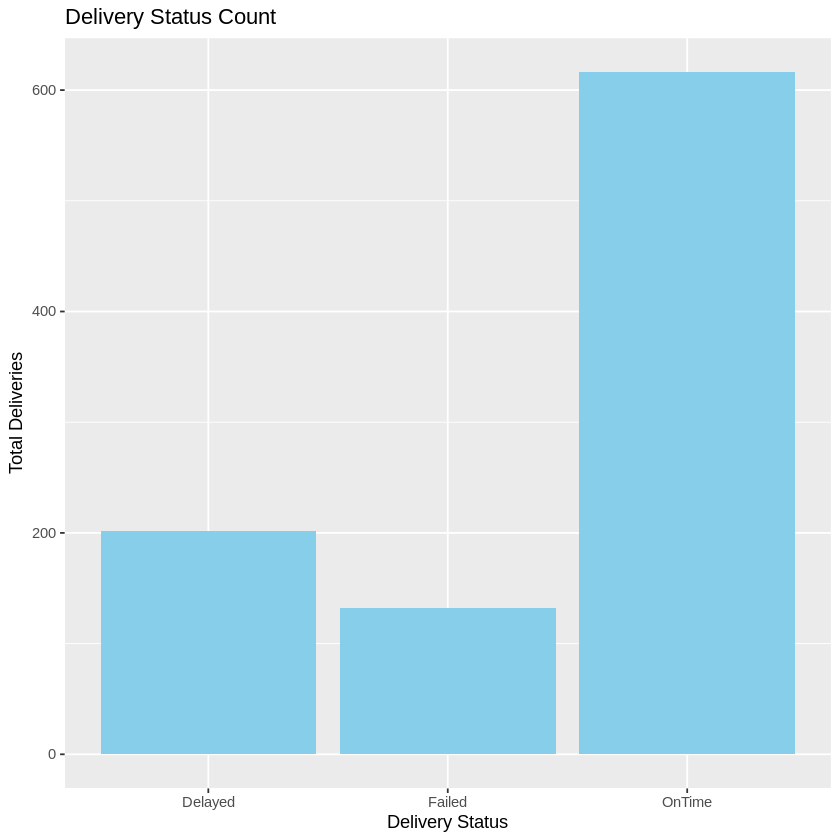

In [ ]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "skyblue") +
  ggtitle("Delivery Status Count") +
  xlab("Delivery Status") +
  ylab("Total Deliveries")

INTERPRETATION

The chart shows that most deliveries were completed on time. However, there are still significant numbers of delayed and failed deliveries. This indicates operational inefficiencies within NorthStar’s delivery system and supports the case study issue regarding declining service reliability.

Chart 2 - Scatter Plot of Route Distance vs Fuel Cost

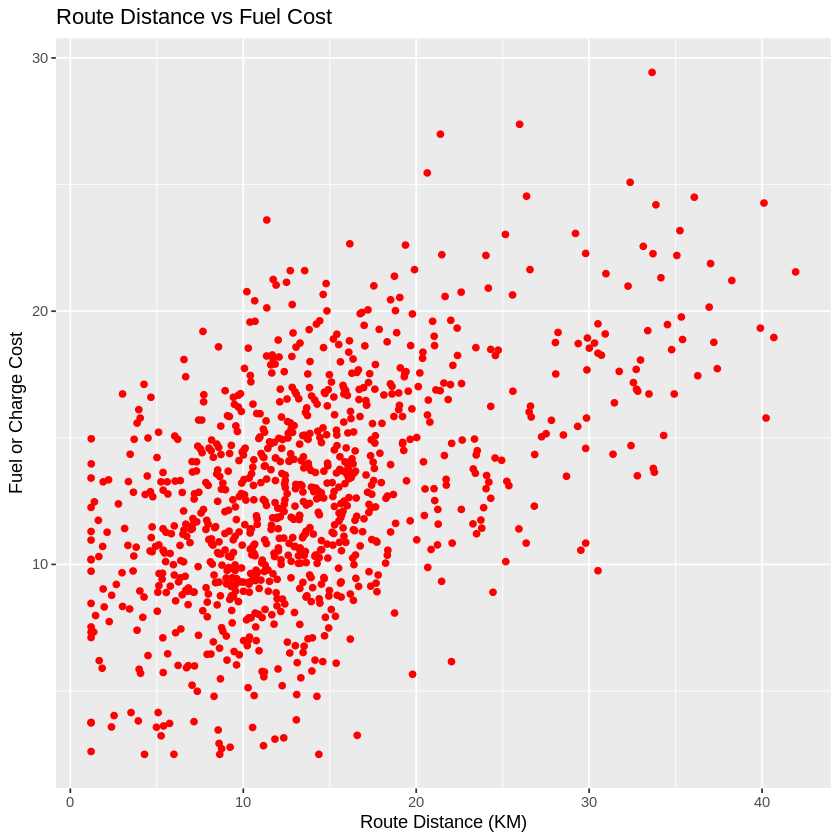

In [ ]:
# Scatter plot for distance vs fuel cost

ggplot(deliveries,
       aes(x = route_distance_km,
           y = fuel_or_charge_cost)) +

  geom_point(color = "red") +

  ggtitle("Route Distance vs Fuel Cost") +

  xlab("Route Distance (KM)") +

  ylab("Fuel or Charge Cost")

INTERPRETATION

The scatter plot shows that fuel or charging costs generally increase as route distance increases. Some deliveries also show unusually high costs, which may indicate inefficient routing or operational inefficiencies.

Chart 3 - Histogram of Driver Ratings

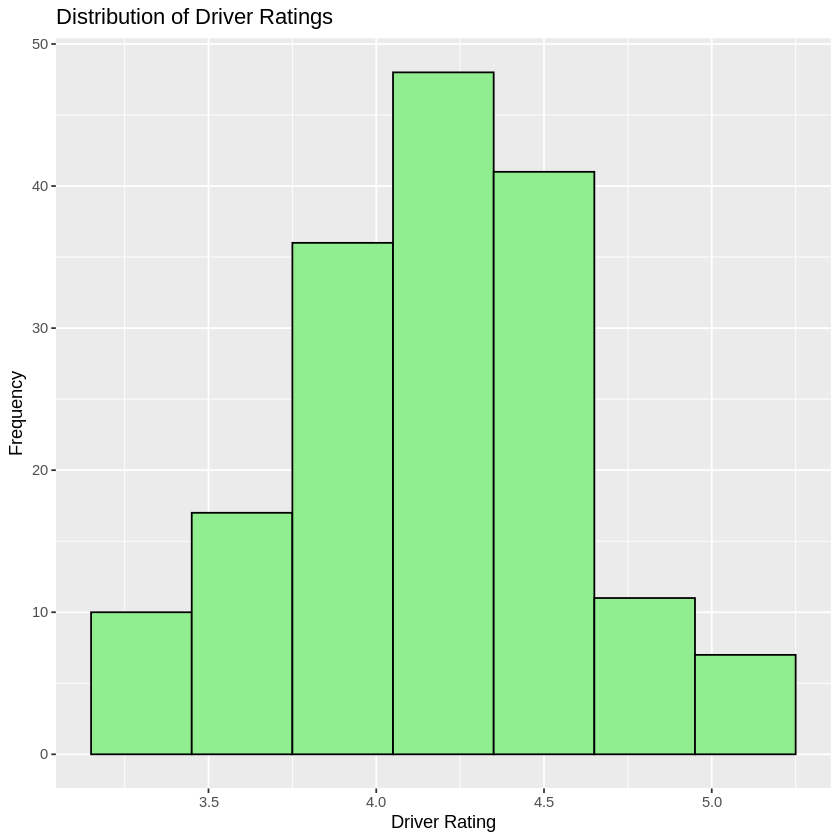

In [ ]:
# Histogram for driver ratings

ggplot(drivers, aes(x = driver_rating)) +

  geom_histogram(binwidth = 0.3,
                 fill = "lightgreen",
                 color = "black") +

  ggtitle("Distribution of Driver Ratings") +

  xlab("Driver Rating") +

  ylab("Frequency")

INTERPRETATION

The histogram shows that most drivers have ratings between 3.5 and 5.0. However, some drivers have low ratings, which may contribute to customer dissatisfaction, delayed deliveries, and service complaints.

Chart 4 - Histogram of Order Values

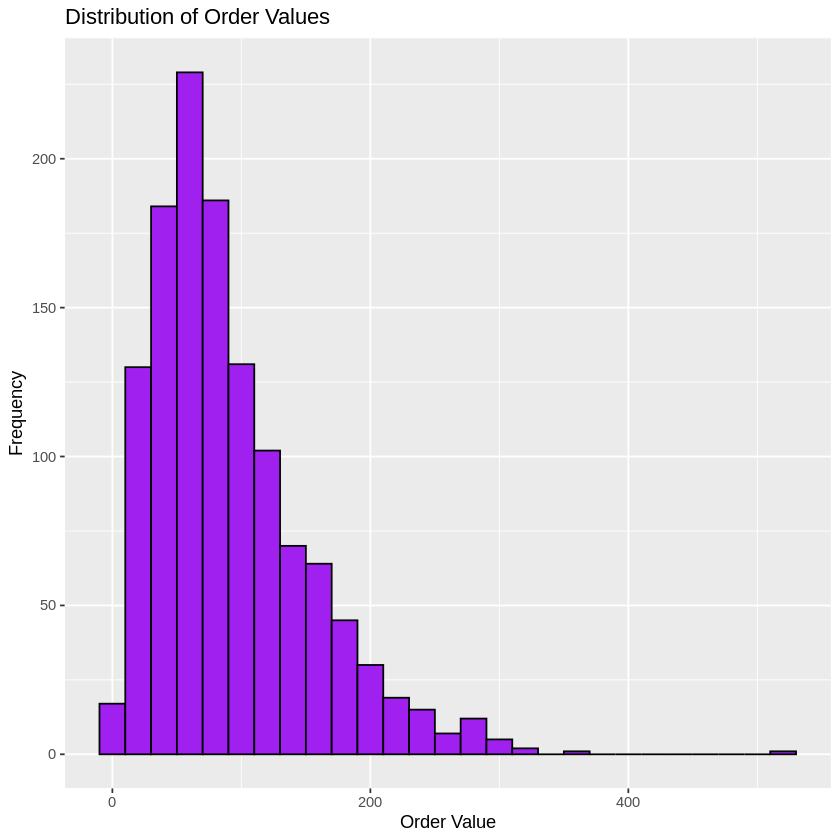

In [ ]:
# Histogram for order values

ggplot(orders, aes(x = order_value)) +

  geom_histogram(binwidth = 20,
                 fill = "purple",
                 color = "black") +

  ggtitle("Distribution of Order Values") +

  xlab("Order Value") +

  ylab("Frequency")

Chart 5- Bar Chart of Complaint Severity

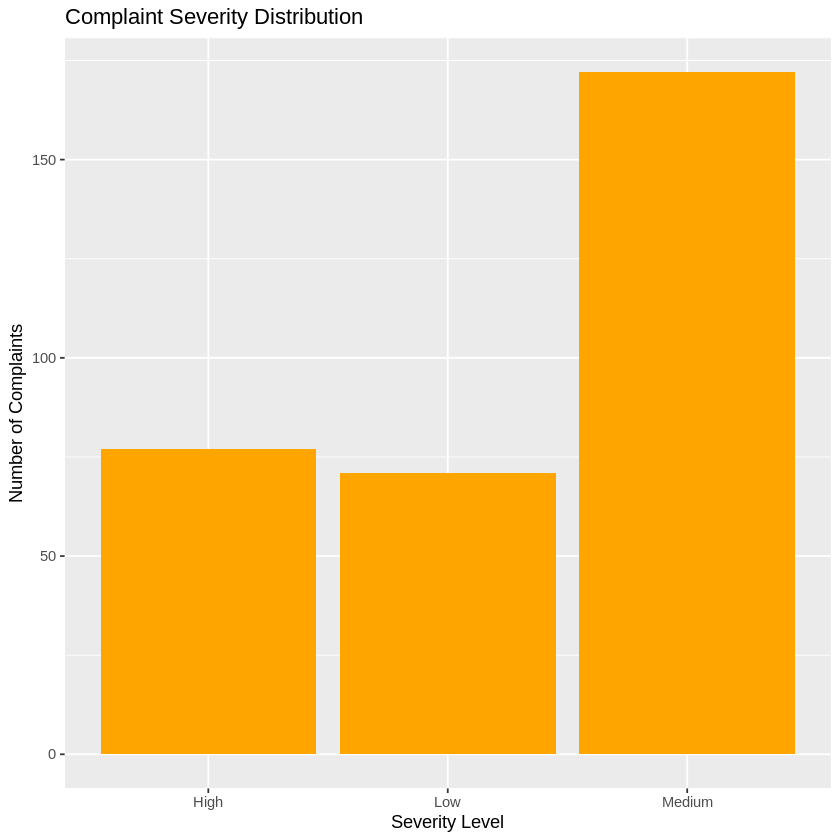

In [ ]:
# Bar chart for complaint severity

ggplot(complaints, aes(x = severity)) +

  geom_bar(fill = "orange") +

  ggtitle("Complaint Severity Distribution") +

  xlab("Severity Level") +

  ylab("Number of Complaints")